#HR Attrition Dataset

**Introduction**

Attrition (Employee Resignation) เป็นปัญหาที่ส่งผลกระทบต่อธุระกิจ โดยการลาออกของพนักอาจจะไม่เกี่ยวข้องกับ geography, industry หรือ size ของบริษัทว่าเล็ก กลาง ใหญ่ขนาดไหน, การลาออกของพนักงานทำให้เกิด cost ที่สำคัญสำหรับธุรกิจ ซึ่งรวมถึงค่าใช้จ่ายในการหยุดชะงักของธุรกิจ การจ้างพนักงานใหม่ และการฝึกอบรมพนักงานใหม่อีกด้วย

ด้วยเหตุนี้ จึงมีเป็นสิ่งที่น่าใจอย่างมากในการทำความเข้าใจปัจจัย การขับเคลื่อน และลดอัตราการออกของพนักงาน จึงอยากจะทดลองใช้ machine learning prediction และดูว่าเราสามารถ predict การลาออกของพนักงานใน dataset: IBM HR Attrition นี้ได้หรือไม่

โดย notebook จะมีขั้นตอนหลักๆ ดังนี้:

**1. Exploratory Data Analysis**

**2. Feature Engineering and Categorical Encoding**

**3. Implementing Machine Learning models**

Source dataset:
https://www.kaggle.com/pavansubhasht/ibm-hr-analytics-attrition-dataset


#_ Import Library & Load Dataset

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re 

# General pandas options
pd.set_option('display.max_colwidth', -1)  # Show the entire column 
pd.options.display.max_columns = 100 
pd.options.display.max_rows = 10000 

from scipy import stats
# from functools import reduce

# Some matplotlib options
%matplotlib inline
matplotlib.style.use("ggplot")

# Seaborn options
sns.set_style("whitegrid")
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import model_selection, tree, preprocessing ,metrics
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.ensemble import ExtraTreesClassifier # feature importance 
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV # tune paramenters

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  if __name__ == '__main__':


In [ ]:
# Load the dataset จาก GitHub   
url = "https://raw.githubusercontent.com/surasak-chantarach/dataset/main/IBM%20HR%20Data3.csv"
data = pd.read_csv(url)
# data = pd.read_csv("IBM HR Data3.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23532 entries, 0 to 23531
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       23529 non-null  float64
 1   Attrition                 23519 non-null  object 
 2   BusinessTravel            23524 non-null  object 
 3   DailyRate                 23521 non-null  float64
 4   Department                23521 non-null  object 
 5   DistanceFromHome          23523 non-null  float64
 6   Education                 23520 non-null  float64
 7   EducationField            23523 non-null  object 
 8   EmployeeCount             23527 non-null  float64
 9   EmployeeNumber            23532 non-null  object 
 10  Application ID            23529 non-null  object 
 11  EnvironmentSatisfaction   23523 non-null  float64
 12  Gender                    23522 non-null  object 
 13  HourlyRate                23523 non-null  float64
 14  JobInv

In [ ]:
# ดูจำนวน row: 23,532, column:37 ทั้งหมด
print(data.shape)

(23532, 37)


In [ ]:
# include='all' แสดงทุก data types
data.describe(include='all')

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,Application ID,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Employee Source
count,23529.000000,23519,23524,23521.000000,23521,23523.000000,23520.000000,23523,23527.0,23532,23529,23523.000000,23522,23523.000000,23523.000000,23525.000000,23523,23523.000000,23521,23518.000000,23521.000000,23523.000000,23522,23520,23518.000000,23522.000000,23524.000000,23522.0,23523.000000,23524.000000,23521.000000,23522.000000,23519.000000,23517.000000,23521.000000,23525.000000,23518
unique,NaN,3,3,NaN,3,NaN,NaN,7,NaN,23464,23515,NaN,2,NaN,NaN,NaN,9,NaN,3,NaN,NaN,NaN,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
top,NaN,Current employee,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,23244,123456,NaN,Male,NaN,NaN,NaN,Sales Executive,NaN,Married,NaN,NaN,NaN,Y,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Company Website
freq,NaN,19714,16700,NaN,15351,NaN,NaN,9725,NaN,7,2,NaN,14121,NaN,NaN,NaN,5127,NaN,10751,NaN,NaN,NaN,23522,16847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5428
mean,36.914489,NaN,NaN,802.159985,NaN,9.193215,2.910969,NaN,1.0,NaN,NaN,2.719424,NaN,65.848489,2.728138,2.063889,NaN,2.726055,NaN,6503.737818,14326.382722,2.686647,NaN,NaN,15.208138,3.155131,2.712166,80.0,0.791481,11.264453,2.796947,2.761457,7.006633,4.225581,2.179967,4.122508,NaN
std,9.130328,NaN,NaN,403.219670,NaN,8.097886,1.023712,NaN,0.0,NaN,NaN,1.095752,NaN,20.360329,0.711346,1.106145,NaN,1.101836,NaN,4706.991078,7108.923965,2.497250,NaN,NaN,3.663518,0.362038,1.080056,0.0,0.850289,7.786058,1.289284,0.705965,6.132952,3.625055,3.213593,3.573748,NaN
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,NaN,NaN,1.000000,NaN,30.000000,1.000000,1.000000,NaN,1.000000,NaN,1009.000000,2094.000000,0.000000,NaN,NaN,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,NaN,NaN,2.000000,NaN,48.000000,2.000000,1.000000,NaN,2.000000,NaN,2911.000000,8053.000000,1.000000,NaN,NaN,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,NaN
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,NaN,NaN,3.000000,NaN,66.000000,3.000000,2.000000,NaN,3.000000,NaN,4936.000000,14242.000000,2.000000,NaN,NaN,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,NaN
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,NaN,NaN,4.000000,NaN,83.000000,3.000000,3.000000,NaN,4.000000,NaN,8380.000000,20467.000000,4.000000,NaN,NaN,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,NaN


In [ ]:
# แสดง 5 แรก
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,Application ID,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Employee Source
0,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,1,123456,2.0,Female,94.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,8.0,Y,Yes,11.0,3.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
1,37.0,Voluntary Resignation,Travel_Rarely,807.0,Human Resources,6.0,4.0,Human Resources,1.0,1,123457,1.0,Female,37.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,8.0,Y,Yes,11.0,4.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
2,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,1,123458,2.0,Female,94.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,4.0,Y,Yes,11.0,3.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
3,37.0,Voluntary Resignation,Travel_Rarely,807.0,Human Resources,6.0,4.0,Marketing,1.0,4,123459,1.0,Female,37.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,5.0,Y,Yes,11.0,3.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
4,37.0,Voluntary Resignation,Travel_Rarely,807.0,Human Resources,6.0,4.0,Human Resources,1.0,5,123460,1.0,Female,37.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,8.0,Y,Yes,11.0,3.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral


#1: Data Cleansing

## Drop Null Value

In [ ]:
# Check missing value: มี missing values ทั้ง 37 column
data.isna().any()

Age                         True 
Attrition                   True 
BusinessTravel              True 
DailyRate                   True 
Department                  True 
DistanceFromHome            True 
Education                   True 
EducationField              True 
EmployeeCount               True 
EmployeeNumber              False
Application ID              True 
EnvironmentSatisfaction     True 
Gender                      True 
HourlyRate                  True 
JobInvolvement              True 
JobLevel                    True 
JobRole                     True 
JobSatisfaction             True 
MaritalStatus               True 
MonthlyIncome               True 
MonthlyRate                 True 
NumCompaniesWorked          True 
Over18                      True 
OverTime                    True 
PercentSalaryHike           True 
PerformanceRating           True 
RelationshipSatisfaction    True 
StandardHours               True 
StockOptionLevel            True 
TotalWorkingYe

In [ ]:
# Using isna() to select all rows with NaN under an entire DataFrame:
print("All Rows, Columns ==> ", data.shape)
print("Count NA:", data.isna().sum().sum(), " rows")
data.isna().sum()

All Rows, Columns ==>  (23532, 37)
Count NA: 353  rows


Age                         3 
Attrition                   13
BusinessTravel              8 
DailyRate                   11
Department                  11
DistanceFromHome            9 
Education                   12
EducationField              9 
EmployeeCount               5 
EmployeeNumber              0 
Application ID              3 
EnvironmentSatisfaction     9 
Gender                      10
HourlyRate                  9 
JobInvolvement              9 
JobLevel                    7 
JobRole                     9 
JobSatisfaction             9 
MaritalStatus               11
MonthlyIncome               14
MonthlyRate                 11
NumCompaniesWorked          9 
Over18                      10
OverTime                    12
PercentSalaryHike           14
PerformanceRating           10
RelationshipSatisfaction    8 
StandardHours               10
StockOptionLevel            9 
TotalWorkingYears           8 
TrainingTimesLastYear       11
WorkLifeBalance             10
YearsAtC

In [ ]:
# Drop NA ท้ิง 353 ค่า 233 แถว เหลือ 23,299 แถว
data.dropna(axis=0, inplace=True)

print("Remaining Rows, Columns ==> ", data.shape)
print("Count NA:", data.isna().sum().sum(), " rows")
data.isna().sum()

Remaining Rows, Columns ==>  (23299, 37)
Count NA: 0  rows


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
Application ID              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCur

## Drop Duplicated Value

In [ ]:
# Check duplicated value: 28 row
print("Duplicated Rows: ", data[data.duplicated(keep=False)].shape)

# Drop duplicated Value
data.drop_duplicates(inplace=True)

print("Remaining Rows: ", data.shape)
data.describe()

Duplicated Rows:  (28, 37)
Remaining Rows:  (23285, 37)


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,23285.000000,23285.000000,23285.000000,23285.000000,23285.0,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.0,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000
mean,36.900923,802.572686,9.215933,2.909856,1.0,2.720636,65.843504,2.728967,2.065149,2.726433,6505.657419,14324.659695,2.690917,15.212626,3.155293,2.712304,80.0,0.792914,11.272665,2.797638,2.761306,7.011982,4.229075,2.178742,4.125317
std,9.109214,403.218729,8.100098,1.023890,0.0,1.095071,20.341556,0.711180,1.106473,1.101984,4708.196811,7106.166140,2.498862,3.664955,0.362192,1.080741,0.0,0.849867,7.778903,1.288927,0.705506,6.131937,3.625615,3.211708,3.572935
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8053.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,2.000000,3.000000,4936.000000,14242.000000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.000000,3.000000,3.000000,4.000000,8380.000000,20467.000000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Trim/Strip Value

In [ ]:
# Strip whitespaces/Trim ด้วย short function: lamda
data = data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [ ]:
# Check Type ที่ยังไม่ตรง
data.dtypes
# They all hould be "Binary": Attrition, Over18, OverTime

Age                         float64
Attrition                   object 
BusinessTravel              object 
DailyRate                   float64
Department                  object 
DistanceFromHome            float64
Education                   float64
EducationField              object 
EmployeeCount               float64
EmployeeNumber              object 
Application ID              object 
EnvironmentSatisfaction     float64
Gender                      object 
HourlyRate                  float64
JobInvolvement              float64
JobLevel                    float64
JobRole                     object 
JobSatisfaction             float64
MaritalStatus               object 
MonthlyIncome               float64
MonthlyRate                 float64
NumCompaniesWorked          float64
Over18                      object 
OverTime                    object 
PercentSalaryHike           float64
PerformanceRating           float64
RelationshipSatisfaction    float64
StandardHours               

In [ ]:
# (3) Using isna() to select all rows with NaN under an entire DataFrame:
print("All Rows, Columns ==> ", data.shape)
print("Count NA:", data.isna().sum().sum(), " rows")
data.isna().sum()

All Rows, Columns ==>  (23285, 37)
Count NA: 0  rows


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
Application ID              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCur

In [ ]:
# ดูสถติ ของแต่ล่ะ feature 
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,23285.000000,23285.000000,23285.000000,23285.000000,23285.0,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.0,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000
mean,36.900923,802.572686,9.215933,2.909856,1.0,2.720636,65.843504,2.728967,2.065149,2.726433,6505.657419,14324.659695,2.690917,15.212626,3.155293,2.712304,80.0,0.792914,11.272665,2.797638,2.761306,7.011982,4.229075,2.178742,4.125317
std,9.109214,403.218729,8.100098,1.023890,0.0,1.095071,20.341556,0.711180,1.106473,1.101984,4708.196811,7106.166140,2.498862,3.664955,0.362192,1.080741,0.0,0.849867,7.778903,1.288927,0.705506,6.131937,3.625615,3.211708,3.572935
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8053.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,2.000000,3.000000,4936.000000,14242.000000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.000000,3.000000,3.000000,4.000000,8380.000000,20467.000000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
data.dropna(axis=1, how='all')

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,Application ID,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Employee Source
0,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,1,123456,2.0,Female,94.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,8.0,Y,Yes,11.0,3.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
1,37.0,Voluntary Resignation,Travel_Rarely,807.0,Human Resources,6.0,4.0,Human Resources,1.0,1,123457,1.0,Female,37.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,8.0,Y,Yes,11.0,4.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
2,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,1,123458,2.0,Female,94.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,4.0,Y,Yes,11.0,3.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
3,37.0,Voluntary Resignation,Travel_Rarely,807.0,Human Resources,6.0,4.0,Marketing,1.0,4,123459,1.0,Female,37.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,5.0,Y,Yes,11.0,3.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
4,37.0,Voluntary Resignation,Travel_Rarely,807.0,Human Resources,6.0,4.0,Human Resources,1.0,5,123460,1.0,Female,37.0,3.0,2.0,Sales Executive,4.0,Single,5993.0,19479.0,8.0,Y,Yes,11.0,3.0,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23524,38.0,Current employee,Travel_Rarely,371.0,Research & Development,2.0,3.0,Life Sciences,1.0,23511,146966,4.0,Male,45.0,3.0,1.0,Research Scientist,4.0,Single,3944.0,4306.0,2.0,Y,Yes,11.0,3.0,3.0,80.0,0.0,6.0,3.0,3.0,3.0,2.0,1.0,2.0,Company Website
23526,34.0,Current employee,Travel_Rarely,629.0,Research & Development,27.0,2.0,Medical,1.0,23513,146968,4.0,Female,95.0,3.0,1.0,Research Scientist,2.0,Single,2311.0,5711.0,2.0,Y,No,15.0,3.0,4.0,80.0,0.0,9.0,3.0,3.0,3.0,2.0,1.0,2.0,Company Website
23529,55.0,Current employee,Non-Travel,177.0,Research & Development,8.0,1.0,Medical,1.0,23516,146971,4.0,Female,84.0,3.0,3.0,Manufacturing Director,1.0,Married,10008.0,12023.0,1.0,Y,Yes,14.0,3.0,4.0,80.0,0.0,31.0,3.0,3.0,2.0,0.0,2.0,2.0,Recruit.net
23530,27.0,Current employee,Travel_Rarely,1134.0,Research & Development,16.0,4.0,Technical Degree,1.0,23517,146972,4.0,Male,98.0,3.0,1.0,Human Resources,2.0,Married,2991.0,5224.0,0.0,Y,Yes,11.0,4.0,2.0,80.0,1.0,7.0,2.0,3.0,6.0,2.0,1.0,2.0,Company Website


## Convert Features Data Type to be Correct Data types
**DistanceFromHome, HourlyRate, JobSatisfaction, MonthlyIncome, PercentSalaryHike**

In [ ]:
# It's the same for the other columns. Let's cast them to floats.
cols = ['DistanceFromHome','JobSatisfaction', 'HourlyRate', 'MonthlyIncome', 'PercentSalaryHike']
data[cols] = data[cols].applymap(np.float64)

In [ ]:
print(data.dtypes)
data.describe()

Age                         float64
Attrition                   object 
BusinessTravel              object 
DailyRate                   float64
Department                  object 
DistanceFromHome            float64
Education                   float64
EducationField              object 
EmployeeCount               float64
EmployeeNumber              object 
Application ID              object 
EnvironmentSatisfaction     float64
Gender                      object 
HourlyRate                  float64
JobInvolvement              float64
JobLevel                    float64
JobRole                     object 
JobSatisfaction             float64
MaritalStatus               object 
MonthlyIncome               float64
MonthlyRate                 float64
NumCompaniesWorked          float64
Over18                      object 
OverTime                    object 
PercentSalaryHike           float64
PerformanceRating           float64
RelationshipSatisfaction    float64
StandardHours               

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,23285.000000,23285.000000,23285.000000,23285.000000,23285.0,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.0,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000,23285.000000
mean,36.900923,802.572686,9.215933,2.909856,1.0,2.720636,65.843504,2.728967,2.065149,2.726433,6505.657419,14324.659695,2.690917,15.212626,3.155293,2.712304,80.0,0.792914,11.272665,2.797638,2.761306,7.011982,4.229075,2.178742,4.125317
std,9.109214,403.218729,8.100098,1.023890,0.0,1.095071,20.341556,0.711180,1.106473,1.101984,4708.196811,7106.166140,2.498862,3.664955,0.362192,1.080741,0.0,0.849867,7.778903,1.288927,0.705506,6.131937,3.625615,3.211708,3.572935
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8053.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,2.000000,3.000000,4936.000000,14242.000000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.000000,3.000000,3.000000,4.000000,8380.000000,20467.000000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Remove Uniqe/Key and Irrelevant Feature

In [ ]:
# ทำการลบ feature ที่แน่นอนว่าใช้ไม่ได้
data = data.drop(['EmployeeCount', 'Over18', "StandardHours", "EmployeeNumber","Application ID"], 1)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  


In [ ]:
# Lets try find some more funky rows
print("All rows, columns: ", data.shape)
for col in data:
    print(col)
    print(data[col].unique())
    print("\n")

All rows, columns:  (23285, 32)
Age
[41. 37. 49. 59. 54. 33. 30. 27. 31. 58. 26. 25. 18. 32. 34. 44. 28. 24.
 36. 39. 38. 20. 40. 45. 47. 35. 29. 42. 57. 50. 43. 22. 51. 53. 21. 55.
 46. 48. 56. 23. 19. 52. 60.]


Attrition
['Voluntary Resignation' 'Current employee' 'Termination']


BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']


DailyRate
[1102.  807.  279. 1420.  142. 1373. 1392. 1240.  591.  106.  682. 1449.
  622.  230.  326. 1005.  988.  489. 1117. 1287.  566.  592. 1324.  427.
  636.  448.  334. 1445. 1358.  314.  827.  506.  254. 1105.  523.  216.
  141.  871.  444. 1365.  906.  981. 1162.  804.  167.  602.  336.  192.
 1225. 1299. 1041.  665.  950.  538.  849. 1467.  809.  829. 1040.  889.
  525.  390.  153. 1075.  555.  798. 1249.  405.  670.  433. 1115.  558.
 1490. 1346.  147.  240. 1232.  959.  553.  660.  103. 1147. 1280.  185.
  830. 1389.  888.  534. 1302.  782. 1220. 1246. 1456.  362. 1377.  330.
 1123. 1219.  552.  600.  371.  673. 1336. 1218.  359

In [ ]:
# ยังมี สาขาที่จบ: "Test" จะเปลี่ยน "Test" ==> "Other"
data.loc[(data['EducationField'] == 'Test')]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Employee Source
16740,49.0,Current employee,Travel_Rarely,1495.0,Research & Development,5.0,4.0,Test,1.0,Male,96.0,3.0,2.0,Healthcare Representative,3.0,Married,6651.0,21534.0,0.0,No,14.0,3.0,2.0,1.0,20.0,0.0,2.0,3.0,2.0,1.0,2.0,Recruit.net


In [ ]:
# ไม่มี EducationField = "Test" แล้ว
data.loc[(data['EducationField'] == 'Test'),'EducationField'] = 'Other'
data.loc[(data['EducationField'] == 'Test')]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Employee Source


In [ ]:
# ลบ row: Employee Source == 'Test'
print(data.shape)
data.loc[(data['Employee Source'] == 'Test')]
data.drop(data[data['Employee Source'] == 'Test'].index, inplace = True)
print(data.shape)

(23285, 32)
(23284, 32)


In [ ]:
ds = data
df_cleaned = data

#แปลงค่า Attrion ก่อน export ไปทำ PowerBI Dashboard
# Termination, Voluntary Resignation ==> "Inactive"
# Current employee ==> "Active"
df_cleaned['Attrition'].replace(to_replace='Voluntary Resignation', value='Inactive', inplace=True)
df_cleaned['Attrition'].replace(to_replace='Termination',  value='Inactive', inplace=True)
df_cleaned['Attrition'].replace(to_replace='Current employee',  value='Active', inplace=True)
df_cleaned.to_csv("ibm-hr-dataset_cleaned.csv")

In [ ]:
print(ds.shape)
ds.describe()

(23284, 32)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000
mean,36.901306,802.563821,9.216286,2.909852,2.720581,65.842768,2.728956,2.065152,2.726422,6505.709157,14325.148686,2.690689,15.212635,3.155300,2.712292,0.792862,11.272977,2.797672,2.761338,7.012197,4.229213,2.178749,4.125408
std,9.109222,403.225118,8.100093,1.023912,1.095063,20.341682,0.711193,1.106496,1.102007,4708.291299,7105.926970,2.498673,3.665034,0.362198,1.080762,0.849849,7.778924,1.288944,0.705503,6.131981,3.625631,3.211777,3.572984
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8053.000000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4936.000000,14242.000000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.000000,3.000000,3.000000,4.000000,8380.000000,20467.000000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


#**2: EDA: Exploratory Data Analysis**

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23284 entries, 0 to 23531
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       23284 non-null  float64
 1   Attrition                 23284 non-null  object 
 2   BusinessTravel            23284 non-null  object 
 3   DailyRate                 23284 non-null  float64
 4   Department                23284 non-null  object 
 5   DistanceFromHome          23284 non-null  float64
 6   Education                 23284 non-null  float64
 7   EducationField            23284 non-null  object 
 8   EnvironmentSatisfaction   23284 non-null  float64
 9   Gender                    23284 non-null  object 
 10  HourlyRate                23284 non-null  float64
 11  JobInvolvement            23284 non-null  float64
 12  JobLevel                  23284 non-null  float64
 13  JobRole                   23284 non-null  object 
 14  JobSat

In [ ]:
numeric_cols = ds.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = ds.select_dtypes(include=['object']).columns.tolist()

In [ ]:
ds[numeric_cols].head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,1102.0,1.0,2.0,2.0,94.0,3.0,2.0,4.0,5993.0,19479.0,8.0,11.0,3.0,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
1,37.0,807.0,6.0,4.0,1.0,37.0,3.0,2.0,4.0,5993.0,19479.0,8.0,11.0,4.0,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
2,41.0,1102.0,1.0,2.0,2.0,94.0,3.0,2.0,4.0,5993.0,19479.0,4.0,11.0,3.0,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
3,37.0,807.0,6.0,4.0,1.0,37.0,3.0,2.0,4.0,5993.0,19479.0,5.0,11.0,3.0,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
4,37.0,807.0,6.0,4.0,1.0,37.0,3.0,2.0,4.0,5993.0,19479.0,8.0,11.0,3.0,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0


In [ ]:
ds[categorical_cols]

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime,Employee Source
0,Inactive,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes,Referral
1,Inactive,Travel_Rarely,Human Resources,Human Resources,Female,Sales Executive,Single,Yes,Referral
2,Inactive,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes,Referral
3,Inactive,Travel_Rarely,Human Resources,Marketing,Female,Sales Executive,Single,Yes,Referral
4,Inactive,Travel_Rarely,Human Resources,Human Resources,Female,Sales Executive,Single,Yes,Referral
...,...,...,...,...,...,...,...,...,...
23524,Active,Travel_Rarely,Research & Development,Life Sciences,Male,Research Scientist,Single,Yes,Company Website
23526,Active,Travel_Rarely,Research & Development,Medical,Female,Research Scientist,Single,No,Company Website
23529,Active,Non-Travel,Research & Development,Medical,Female,Manufacturing Director,Married,Yes,Recruit.net
23530,Active,Travel_Rarely,Research & Development,Technical Degree,Male,Human Resources,Married,Yes,Company Website


In [ ]:
# ตรวจสอบ missing value อีกครั้ง
missing_counts = ds[numeric_cols].isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

Series([], dtype: int64)

In [ ]:
missing_counts = ds[categorical_cols].isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

Series([], dtype: int64)

In [ ]:
# ดูค่าทางสถิติของ feature ที่เป็นตัวเลข
ds[numeric_cols].describe()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000,23284.000000
mean,36.901306,802.563821,9.216286,2.909852,2.720581,65.842768,2.728956,2.065152,2.726422,6505.709157,14325.148686,2.690689,15.212635,3.155300,2.712292,0.792862,11.272977,2.797672,2.761338,7.012197,4.229213,2.178749,4.125408
std,9.109222,403.225118,8.100093,1.023912,1.095063,20.341682,0.711193,1.106496,1.102007,4708.291299,7105.926970,2.498673,3.665034,0.362198,1.080762,0.849849,7.778924,1.288944,0.705503,6.131981,3.625631,3.211777,3.572984
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8053.000000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4936.000000,14242.000000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.000000,3.000000,3.000000,4.000000,8380.000000,20467.000000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# นัับจำนวน Label
ds['Attrition'].value_counts()

Active      19527
Inactive    3757 
Name: Attrition, dtype: int64

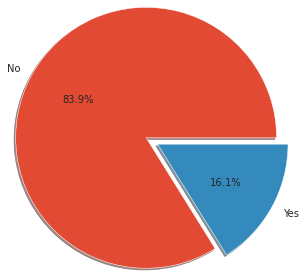

In [ ]:
# Donut Grapth แสดง % Label
r = ds.groupby('Attrition')['Attrition'].count()
plt.pie(r, explode=[0.05, 0.1], labels=['No', 'Yes'], radius=1.5, autopct='%1.1f%%',  shadow=True);

In [ ]:
print("======= Department =======\n", ds['Department'].value_counts(),"\n")
print("======= Education Field =======\n", ds['EducationField'].value_counts(),"\n")
print("======= Job Role =======\n", ds['JobRole'].value_counts(),"\n")

======= Department =======
 Research & Development    15187
Sales                     7088 
Human Resources           1009 
Name: Department, dtype: int64 

======= Education Field =======
 Life Sciences       9594
Medical             7351
Marketing           2524
Technical Degree    2069
Other               1305
Human Resources     441 
Name: EducationField, dtype: int64 

======= Job Role =======
 Sales Executive              5072
Research Scientist           4607
Laboratory Technician        4124
Manufacturing Director       2377
Healthcare Representative    2085
Manager                      1593
Sales Representative         1307
Research Director            1281
Human Resources              838 
Name: JobRole, dtype: int64 



/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


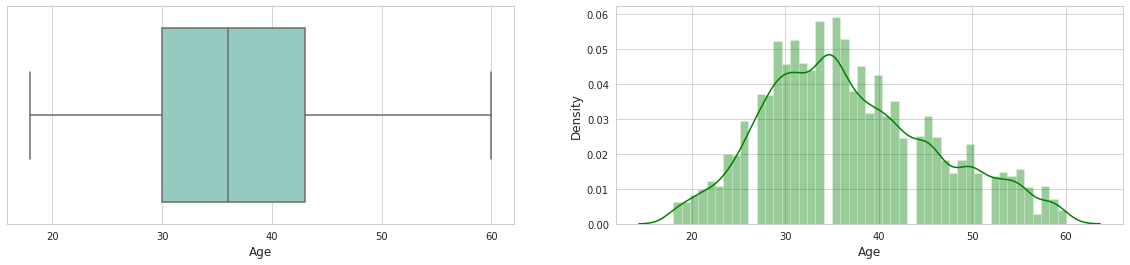

In [ ]:
# ความหนาแน่นของ Age: 30-45 ปี
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
sns.boxplot(ax = axes[0],palette = "Set3", x = ds['Age'])
sns.distplot(ax = axes[1],color = "Green",a=ds["Age"])

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


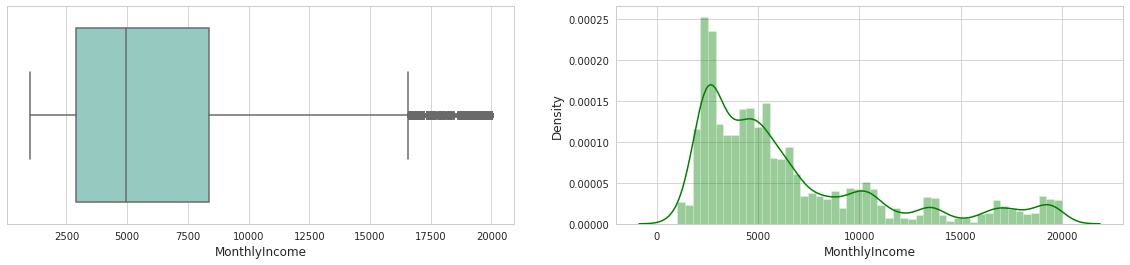

In [ ]:
# ความหนาแน่นของ Monthly Income: 2700 - 800k
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
sns.boxplot(ax = axes[0],palette = "Set3",x = ds['MonthlyIncome'])
sns.distplot(ax = axes[1],color = "Green",a=ds["MonthlyIncome"])

In [ ]:
# พนักงานที่มี Monthly Income > 17500 ซึ่งน่าจะเป็น Outlier
len(ds[ds['MonthlyIncome']>17500])

1290

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


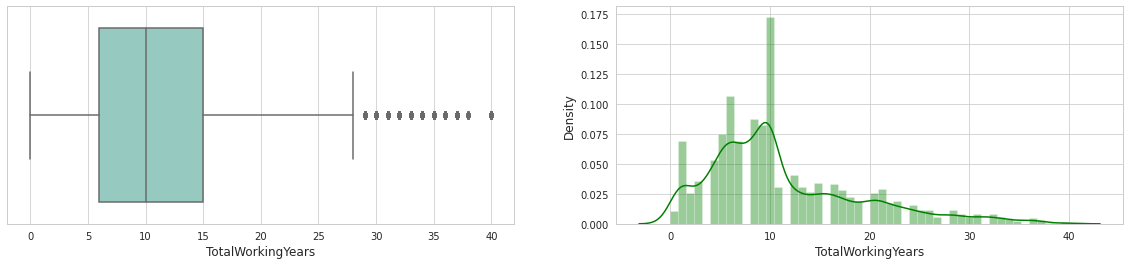

In [ ]:
# พนักงานส่วนใหญ่มีจำนวน Working Year: 5-15 ปี
ig, axes = plt.subplots(1, 2, figsize=(20, 4))
sns.boxplot(ax = axes[0],palette = "Set3", x = ds['TotalWorkingYears'])
sns.distplot(ax = axes[1],color = "Green" ,a = ds["TotalWorkingYears"])

In [ ]:
# พนักงานส่วนที่มี Working Year >  28 ปี, น่าจะเป็นพนักงานที่กำลังจะ retire หรือ retired แล้ว
len(ds[ds['TotalWorkingYears']>28])

996

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


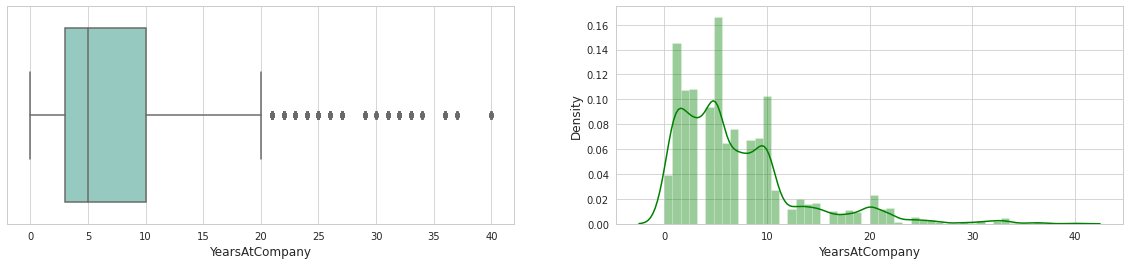

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
sns.boxplot(ax = axes[0],palette = "Set3",x = ds['YearsAtCompany'])
sns.distplot(ax = axes[1],color = "Green" ,a=ds["YearsAtCompany"])

In [ ]:
# จำนวนที่ทำงานที่บริษัท > 18 ปี
len(ds[ds['YearsAtCompany']>18])

1650

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


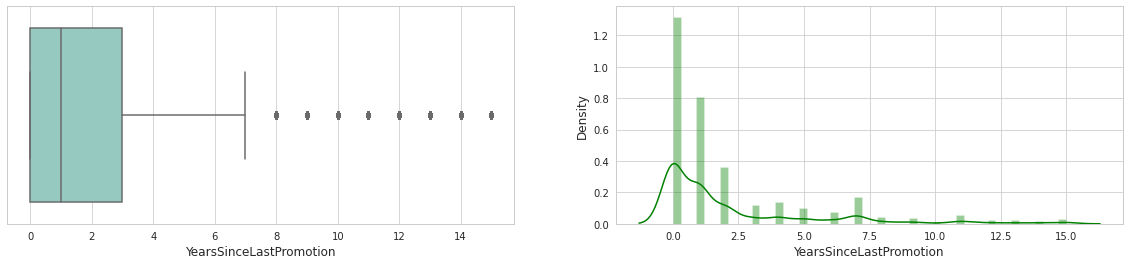

In [ ]:
# จำนวนปี นับจากการ promote ล่าสุด
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
sns.boxplot(ax = axes[0], palette = "Set3", x = ds['YearsSinceLastPromotion'])
sns.distplot(ax = axes[1],color = "Green", a=ds["YearsSinceLastPromotion"])

In [ ]:
# > 7 ปี
len(ds[ds['YearsSinceLastPromotion']>7])

1675

In [ ]:
# < 7 ปี ซึ่งอยุ่ในกลุ่มส่วนใหญ่
len(ds[ds['YearsSinceLastPromotion']<7])

20403

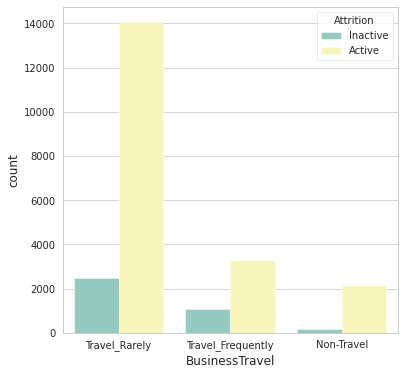

In [ ]:
# พนักงานที่ Active ยังออก business trip มากกว่า
# sns.palplot(sns.)
plt.figure(figsize=(6,6))
sns.countplot(x='BusinessTravel',palette = "Set3", hue='Attrition', data=ds);

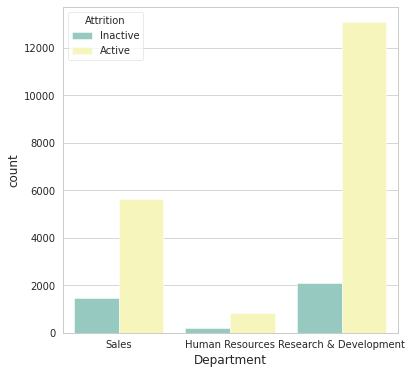

In [ ]:
# สัดส่วนพนักงาน Active/Inactive, R&D จะมีพนักงานลาออกมากสุด จากทั้งหมด 3 dept
plt.figure(figsize=(6,6))
sns.countplot(x='Department', hue='Attrition', palette = "Set3", data=ds);

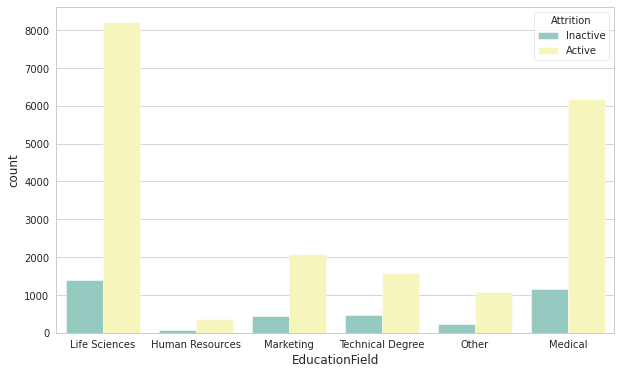

In [ ]:
# สัดส่วนพนักงาน Active/Inactive ตามสาขาที่จบ
plt.figure(figsize=(10,6))
sns.countplot(x='EducationField', hue='Attrition', palette = "Set3", data=ds);

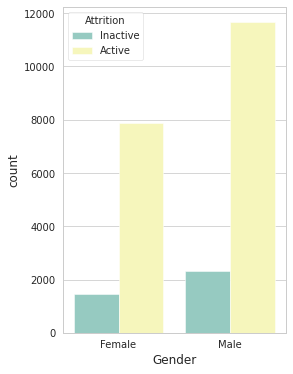

In [ ]:
# สัดส่วนพนักงาน Active/Inactive ต่อ Gender
plt.figure(figsize=(4,6))
sns.countplot(x='Gender', hue='Attrition', palette = "Set3", data=ds);

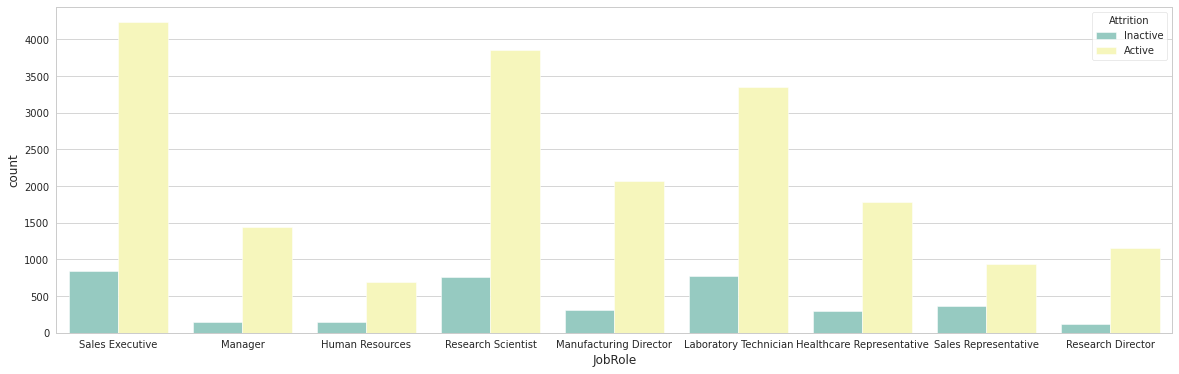

In [ ]:
# สัดส่วนพนักงาน Active/Inactive ต่อ ระดับตำแหน่ง
plt.figure(figsize=(20,6))
sns.countplot(x='JobRole', hue='Attrition', palette = "Set3", data=ds);

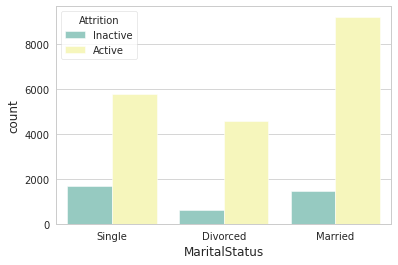

In [ ]:
# สัดส่วนพนักงาน Active/Inactive ต่อ สถานภาพสมรส
sns.countplot(x='MaritalStatus', hue='Attrition', palette = "Set3", data=ds);

**Finding Correlations**


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


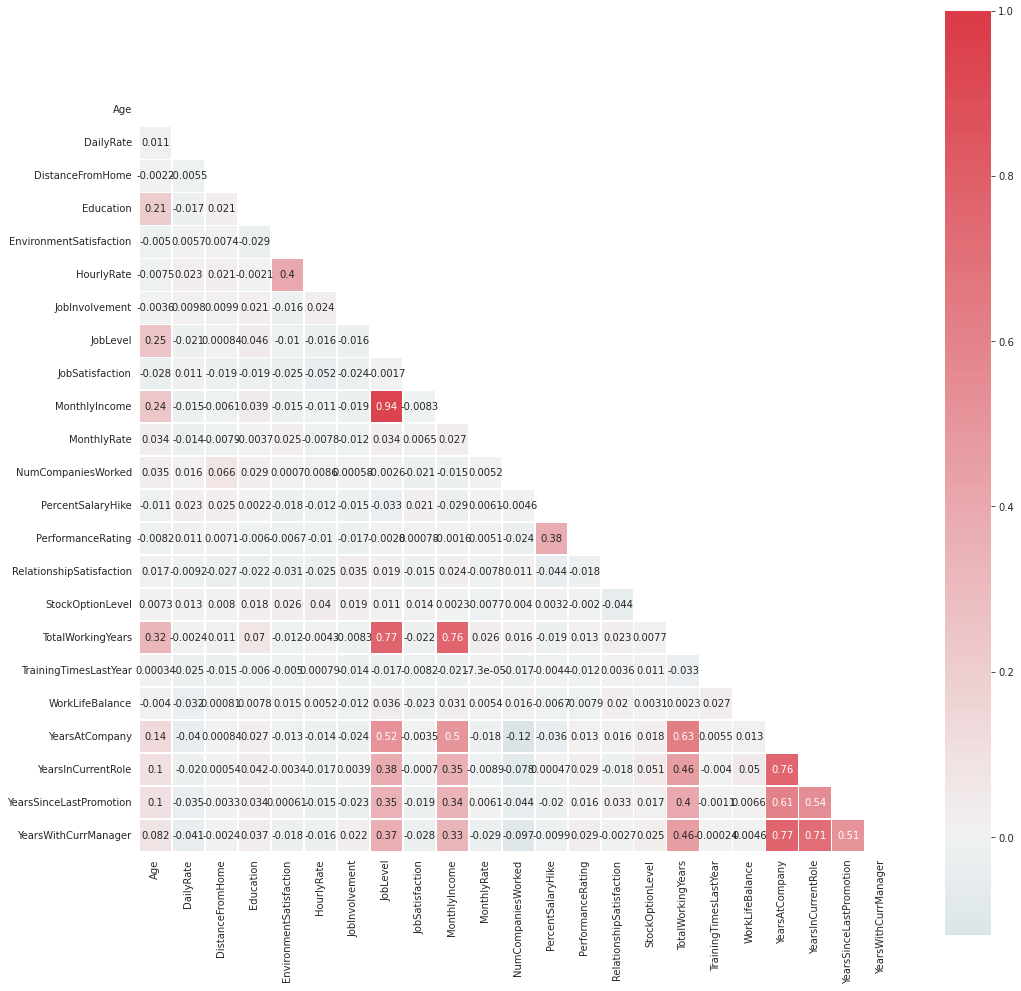

In [ ]:
# Subset the dataset into all the numerical values
numeric_hr = ds.select_dtypes(include=[np.number])

# Compete the correlation matrix
corr = numeric_hr._get_numeric_data().corr()

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(17, 17))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
heatmap = sns.heatmap(corr, annot=True, mask=mask, cmap=cmap, center=0.0,
                      vmax = 1, square=True, linewidths=.5, ax=ax)
plt.savefig('corr-heat.png')
plt.show()

*   **`TotalWorkingYears`** correlate กับ **`Job Level`** สูง เนื่องจากทำงานนานก็จะมี job level ที่สูง
*   **`MonthlyIncome`** สัมพันธ์กับ **`Job Level`** แต่ยังไงก็จะใช้ feature นี้ต่อไป
*   **`HourlyRate, DailyRate, และ MonthlyRate`** ไม่มีความสัมพันธ์กันซักเท่าไหร่ 
*   **`Age`** correlate กับ **`JobLevel`**, **`Education`** (เมื่ออายุมาก ก็มีตำแหน่งและการศึกษา ที่สูงขึ้น)
*   **`TotalWorkdingYear`** correlate กับ feature ที่เกียวกับการนับอายุงาน เช่น **`YearsWithCurrentManager, YearsSinceLastPromotion, YearsInCurrentRole, YearsAtCompany`**


#3: Feature Selection


##  Feature Importance

จาก Feature ทั้งหมด 32 จะทำการหาตัวแปรที่สำคัญ

In [ ]:
print(ds.shape)
print(ds.columns)

(23284, 32)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Employee Source'],
      dtype='object')


### OneHotEncoder

In [ ]:
# OneHotEncoder กับทุก feature เพื่อให้แน่ใจว่าเป็น numerical ทุก feature แล้ว
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, LabelBinarizer

ds = data.apply(LabelEncoder().fit_transform)
ds.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Employee Source
0,23,1,2,624,2,0,1,1,1,0,64,2,1,7,3,2,809,999,8,1,0,0,0,0,8,0,0,6,4,0,5,7
1,19,1,2,451,0,5,3,0,0,0,7,2,1,7,3,2,809,999,8,1,0,1,0,0,8,0,0,6,4,0,5,7
2,23,1,2,624,2,0,1,1,1,0,64,2,1,7,3,2,809,999,4,1,0,0,0,0,8,0,0,6,4,0,5,7
3,19,1,2,451,0,5,3,2,0,0,7,2,1,7,3,2,809,999,5,1,0,0,0,0,8,0,0,6,4,0,5,7
4,19,1,2,451,0,5,3,0,0,0,7,2,1,7,3,2,809,999,8,1,0,0,0,0,8,0,0,6,4,0,5,7


### Find Importances Feature by Tree Classifier

In [ ]:
# แสดง feature ทั้งหมด
print(ds.shape)
print(ds.columns)
print(ds.dtypes)

(23284, 32)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Employee Source'],
      dtype='object')
Age                         int64
Attrition                   int64
BusinessTravel              int64
DailyRate                   int64
Department                  int64
DistanceFromHome            int64
Education                   int64
EducationField              int64
EnvironmentSatisfaction     int64
Gender               

In [ ]:
#  ใช้ Tree Classification ในการหา importance feature

model= RandomForestClassifier(n_estimators=250, random_state=100)
# model= DecisionTreeClassifier(random_state=100)
# model= ExtraTreesClassifier(n_estimators=1000, random_state=100)
X = ds[['Age','BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Employee Source']]
y = ds['Attrition']
model.fit(X,y)

RandomForestClassifier(n_estimators=250, random_state=100)

In [ ]:
# Percentage ของแต่ละ Feature
fs = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
fs

PerformanceRating           0.001681
Gender                      0.009622
EducationField              0.012352
NumCompaniesWorked          0.012623
JobLevel                    0.016034
MaritalStatus               0.017680
WorkLifeBalance             0.018817
BusinessTravel              0.020104
StockOptionLevel            0.020313
Department                  0.020420
JobInvolvement              0.020925
RelationshipSatisfaction    0.022935
OverTime                    0.022946
JobSatisfaction             0.023347
YearsSinceLastPromotion     0.024975
YearsInCurrentRole          0.026226
EnvironmentSatisfaction     0.026785
Employee Source             0.026795
TrainingTimesLastYear       0.027041
YearsWithCurrManager        0.027650
Education                   0.028370
JobRole                     0.028373
YearsAtCompany              0.032963
PercentSalaryHike           0.037381
TotalWorkingYears           0.043497
MonthlyRate                 0.049422
DistanceFromHome            0.063219
M

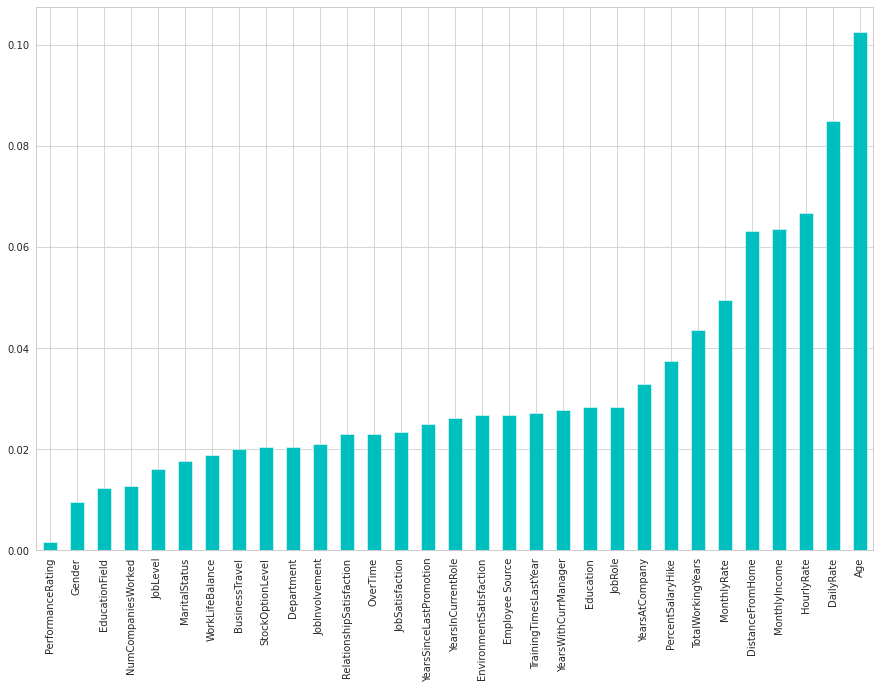

In [ ]:
plt.figure(figsize=(15,10))
fs.plot(kind='bar', color='c')

In [ ]:
# ผลที่ได้่ มี feature ที่มีความสำคัญ > 3% มีเพียง  9/32 อาจจะถูกตัดไปเยอะเกินไป
pct = 0.03
print(fs[fs > pct].shape, "\n")
print(fs[fs > pct], "\n")
print(fs[fs > pct].index)

(9,) 

YearsAtCompany       0.032963
PercentSalaryHike    0.037381
TotalWorkingYears    0.043497
MonthlyRate          0.049422
DistanceFromHome     0.063219
MonthlyIncome        0.063532
HourlyRate           0.066707
DailyRate            0.084867
Age                  0.102395
dtype: float64 

Index(['YearsAtCompany', 'PercentSalaryHike', 'TotalWorkingYears',
       'MonthlyRate', 'DistanceFromHome', 'MonthlyIncome', 'HourlyRate',
       'DailyRate', 'Age'],
      dtype='object')


In [ ]:
# เลือก feature ที่มีความสำคัญ > 2.5% เพื่อยังคง ตัวแปรที่มาก  16/32
pct = 0.025
print(fs[fs > pct].shape, "\n")
print(fs[fs > pct], "\n")
print(fs[fs > pct].index)

(16,) 

YearsInCurrentRole         0.026226
EnvironmentSatisfaction    0.026785
Employee Source            0.026795
TrainingTimesLastYear      0.027041
YearsWithCurrManager       0.027650
Education                  0.028370
JobRole                    0.028373
YearsAtCompany             0.032963
PercentSalaryHike          0.037381
TotalWorkingYears          0.043497
MonthlyRate                0.049422
DistanceFromHome           0.063219
MonthlyIncome              0.063532
HourlyRate                 0.066707
DailyRate                  0.084867
Age                        0.102395
dtype: float64 

Index(['YearsInCurrentRole', 'EnvironmentSatisfaction', 'Employee Source',
       'TrainingTimesLastYear', 'YearsWithCurrManager', 'Education', 'JobRole',
       'YearsAtCompany', 'PercentSalaryHike', 'TotalWorkingYears',
       'MonthlyRate', 'DistanceFromHome', 'MonthlyIncome', 'HourlyRate',
       'DailyRate', 'Age'],
      dtype='object')


### Selected Features


In [ ]:
fs

PerformanceRating           0.001681
Gender                      0.009622
EducationField              0.012352
NumCompaniesWorked          0.012623
JobLevel                    0.016034
MaritalStatus               0.017680
WorkLifeBalance             0.018817
BusinessTravel              0.020104
StockOptionLevel            0.020313
Department                  0.020420
JobInvolvement              0.020925
RelationshipSatisfaction    0.022935
OverTime                    0.022946
JobSatisfaction             0.023347
YearsSinceLastPromotion     0.024975
YearsInCurrentRole          0.026226
EnvironmentSatisfaction     0.026785
Employee Source             0.026795
TrainingTimesLastYear       0.027041
YearsWithCurrManager        0.027650
Education                   0.028370
JobRole                     0.028373
YearsAtCompany              0.032963
PercentSalaryHike           0.037381
TotalWorkingYears           0.043497
MonthlyRate                 0.049422
DistanceFromHome            0.063219
M

# Splitting the Data
Set Features

In [ ]:
#Convertin the predictor variable in a binary numeric variable
ds['Attrition'].replace(to_replace='Voluntary Resignation', value=1, inplace=True)
ds['Attrition'].replace(to_replace='Termination',  value=1, inplace=True)
ds['Attrition'].replace(to_replace='Current employee',  value=0, inplace=True)

In [ ]:
# Encode the All of Features
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, LabelBinarizer
# Transform
ds = ds.apply(LabelEncoder().fit_transform)
ds.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Employee Source
0,23,1,2,624,2,0,1,1,1,0,64,2,1,7,3,2,809,999,8,1,0,0,0,0,8,0,0,6,4,0,5,7
1,19,1,2,451,0,5,3,0,0,0,7,2,1,7,3,2,809,999,8,1,0,1,0,0,8,0,0,6,4,0,5,7
2,23,1,2,624,2,0,1,1,1,0,64,2,1,7,3,2,809,999,4,1,0,0,0,0,8,0,0,6,4,0,5,7
3,19,1,2,451,0,5,3,2,0,0,7,2,1,7,3,2,809,999,5,1,0,0,0,0,8,0,0,6,4,0,5,7
4,19,1,2,451,0,5,3,0,0,0,7,2,1,7,3,2,809,999,8,1,0,0,0,0,8,0,0,6,4,0,5,7


In [ ]:
# Importance Features ( 16 of 32)
X = ds[['YearsInCurrentRole', 'EnvironmentSatisfaction', 'Employee Source',
       'TrainingTimesLastYear', 'YearsWithCurrManager', 'Education', 'JobRole',
       'YearsAtCompany', 'PercentSalaryHike', 'TotalWorkingYears',
       'MonthlyRate', 'DistanceFromHome', 'MonthlyIncome', 'HourlyRate',
       'DailyRate', 'Age']]
y = ds['Attrition']

In [ ]:
y.value_counts()

0    19527
1    3757 
Name: Attrition, dtype: int64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 100)

In [ ]:
X_train.shape, y_train.shape

((18627, 16), (18627,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=100)
# X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=21)

print("Train Shape:", X_train.shape, y_train.shape)
# print("Validation set Shape:", X_val.shape,y_val.shape)
print("Test set Shape:", X_test.shape, y_test.shape)

Train Shape: (16298, 16) (16298,)
Test set Shape: (6986, 16) (6986,)


In [ ]:
# K-Fold validation = 5
cv = model_selection.KFold(n_splits=5, random_state=None)

# Normalization

In [ ]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
# X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)

X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
X_train.head()

,YearsInCurrentRole,EnvironmentSatisfaction,Employee Source,TrainingTimesLastYear,YearsWithCurrManager,Education,JobRole,YearsAtCompany,PercentSalaryHike,TotalWorkingYears,MonthlyRate,DistanceFromHome,MonthlyIncome,HourlyRate,DailyRate,Age
0,-1.163859,0.250326,1.656970,1.713100,-1.154688,2.055463,-0.986270,-1.153176,-0.052915,-1.453866,0.678341,-0.890315,-1.622827,0.698835,-1.313996,0.114668
1,0.760824,-0.661364,0.522770,0.160344,-0.874463,0.091349,-1.798038,0.162007,-0.872437,-0.041295,1.572881,2.193844,-0.297064,0.011142,-0.337365,-0.871076
2,-0.613950,0.250326,0.144704,0.160344,-0.594237,0.091349,1.043151,-0.659982,-0.326089,-0.426542,-0.223491,1.083547,-0.068396,0.747956,1.005503,-0.213913
3,0.760824,-0.661364,-1.367562,-1.392412,-0.874463,0.091349,-1.798038,0.490803,-1.145611,2.398600,0.850929,0.096616,1.236812,-0.234462,1.430810,-0.323440
4,0.485869,-1.573055,-0.611429,0.936722,1.087116,1.073406,-0.986270,0.326405,-1.145611,-0.169711,-0.879811,-1.013681,-1.124381,-0.873034,-1.522712,-0.323440


# Applying Machine Learning Algorithms

## Logistic Regression

In [ ]:
# lr_clf = LogisticRegression(solver='liblinear', penalty='l1', random_state=4)
lr_clf = LogisticRegression(random_state=100)
lr_clf.fit(X_train, y_train)
prediction_lr = lr_clf.predict(X_test)

score_lr = accuracy_score(y_test, prediction_lr)
print("Accuracy: ", score_lr)
print(classification_report(y_test, prediction_lr))

Accuracy:  0.8342399083882049
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      5834
           1       0.12      0.00      0.00      1152

    accuracy                           0.83      6986
   macro avg       0.48      0.50      0.46      6986
weighted avg       0.72      0.83      0.76      6986



## Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=100)
dt.fit(X_train, y_train)
prediction_dt = dt.predict(X_test)

score_dt = accuracy_score(y_test, prediction_lr)
print("Accuracy: ", score_dt)
print(classification_report(y_test, prediction_lr))


Accuracy:  0.8342399083882049
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      5834
           1       0.12      0.00      0.00      1152

    accuracy                           0.83      6986
   macro avg       0.48      0.50      0.46      6986
weighted avg       0.72      0.83      0.76      6986



## Random Forest

In [ ]:
# Defauted Parameters
rfc = RandomForestClassifier(random_state=100).fit(X_train, y_train)
prediction_rfc = rfc.predict(X_test)

score_rfc = accuracy_score(y_test, prediction_rfc)
print("Accuracy: ", score_rfc)
print(confusion_matrix(y_test, prediction_rfc))
print(classification_report(y_test, prediction_rfc))


Accuracy:  0.9978528485542514
[[5834    0]
 [  15 1137]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5834
           1       1.00      0.99      0.99      1152

    accuracy                           1.00      6986
   macro avg       1.00      0.99      1.00      6986
weighted avg       1.00      1.00      1.00      6986



In [ ]:
# Manual Parameters
rfc = RandomForestClassifier(n_estimators=500, random_state=100).fit(X_train, y_train)
prediction_rfc = rfc.predict(X_test)

score_rfc_manual = accuracy_score(y_test, prediction_rfc)
print("Accuracy: ", score_rfc_manual)
print(confusion_matrix(y_test, prediction_rfc))
print(classification_report(y_test, prediction_rfc))

Accuracy:  0.9978528485542514
[[5834    0]
 [  15 1137]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5834
           1       1.00      0.99      0.99      1152

    accuracy                           1.00      6986
   macro avg       1.00      0.99      1.00      6986
weighted avg       1.00      1.00      1.00      6986



In [ ]:
rfc_params ={
      'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
      'criterion' : ['gini', 'entropy'],
      'max_features': ['sqrt', 'log2','auto'],
      'min_samples_leaf': [2,4,5],
      'min_samples_split': [2,4,6],
      'n_estimators': [100,200,300, 1000]} 

# bigdata.go.th
# rfc_params ={
#       'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
#       'criterion' : ['gini', 'entropy'],
#       'max_features': [0.3,0.5,0.7,0.9],
#       'min_samples_leaf': [3,5,7,10,15],
#       'min_samples_split': [2,5,10],
#       'n_estimators': [50,100,200,400,600]} 

# grid = {'n_estimators': [int(x) for x in np.linspace(start = 100, stop = 500, num = 5)],
# grid_params = {'n_estimators': [int(x) for x in np.linspace(start = 50, stop = 100, num = 5)],
#         'max_features': [None, 'sqrt'],
#         'max_depth': [None, 5, 7, 14, 21],
#         'min_samples_split': [2, 5, 8],
#         'min_samples_leaf': [3, 4, 5],
#         'bootstrap': [True, False]}

In [ ]:
score_rfc_grid = 0
score_rfc_random = 0

In [ ]:
rfc = GridSearchCV(RandomForestClassifier(), rfc_params, cv=5, scoring='accuracy', n_jobs=-1)
rfc.fit(X_train, y_train)
prediction_rfc = rfc.best_estimator_.predict(X_test)

print("Grid Search Params: ", rfc.best_estimator_)
score_rfc_grid = accuracy_score(y_test, prediction_rfc)
print("Accuracy: ", score_rfc_grid)
print(confusion_matrix(y_test, prediction_rfc))
print(classification_report(y_test, prediction_rfc))

In [ ]:
# rfc = RandomForestClassifier()
# rf_cv = RandomizedSearchCV(estimator=rf, param_distributions=grid, scoring='roc_auc', 
#                          n_iter=10, cv=5, random_state=100, n_jobs=-1)

rfc = RandomizedSearchCV(RandomForestClassifier(), param_distributions=rfc_params, scoring='accuracy', cv=5, random_state=100, n_jobs=-1)

rfc.fit(X_train, y_train)
prediction_rfc = rfc.best_estimator_.predict(X_test)

print("Random Params: ", rfc.best_estimator_)
score_rfc_random = accuracy_score(y_test, prediction_rfc)
print("Accuracy: ", score_rfc_random)
print(confusion_matrix(y_test, prediction_rfc))
print(classification_report(y_test, prediction_rfc))

Random Params:  RandomForestClassifier(criterion='entropy', max_depth=50, max_features='log2',
                       min_samples_leaf=2, n_estimators=300)
Accuracy:  0.9957056971085028
[[5834    0]
 [  30 1122]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      5834
           1       1.00      0.97      0.99      1152

    accuracy                           1.00      6986
   macro avg       1.00      0.99      0.99      6986
weighted avg       1.00      1.00      1.00      6986



## Support Vector Classification

In [ ]:
svc = SVC(random_state=100).fit(X_train, y_train)
prediction_svc = svc.predict(X_test)

score_svc = accuracy_score(y_test, prediction_svc)
print("Accuracy: ", score_svc)
print(confusion_matrix(y_test, prediction_svc))
print(classification_report(y_test, prediction_svc))

Accuracy:  0.8809046664758088
[[5811   23]
 [ 809  343]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      5834
           1       0.94      0.30      0.45      1152

    accuracy                           0.88      6986
   macro avg       0.91      0.65      0.69      6986
weighted avg       0.89      0.88      0.85      6986



## KNN

In [ ]:
# Base
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
prediction_knn = knn.predict(X_test)

score_knn = accuracy_score(y_test, prediction_knn)
print("Accuracy: ", score_knn)
print(confusion_matrix(y_test, prediction_knn))
print(classification_report(y_test, prediction_knn))

Accuracy:  0.9808187804179788
[[5793   41]
 [  93 1059]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5834
           1       0.96      0.92      0.94      1152

    accuracy                           0.98      6986
   macro avg       0.97      0.96      0.96      6986
weighted avg       0.98      0.98      0.98      6986



In [ ]:
# Manual Parameters
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)
prediction_knn = knn.predict(X_test)

score_knn_manual = accuracy_score(y_test, prediction_knn)
print("Accuracy: ", score_knn_manual)
print(confusion_matrix(y_test, prediction_knn))
print(classification_report(y_test, prediction_knn))

Accuracy:  0.9896936730604066
[[5821   13]
 [  59 1093]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5834
           1       0.99      0.95      0.97      1152

    accuracy                           0.99      6986
   macro avg       0.99      0.97      0.98      6986
weighted avg       0.99      0.99      0.99      6986



In [ ]:
# KNN Param
k_range = list(range(1, 15))
weight_options = ['uniform', 'distance']
knn_param = dict(n_neighbors=k_range, weights=weight_options)
knn_param

{'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 'weights': ['uniform', 'distance']}

In [ ]:
# Grid Search
knn = GridSearchCV(KNeighborsClassifier(), knn_param, cv=5, scoring='accuracy',)
knn.fit(X_train, y_train)
prediction_knn = knn.best_estimator_.predict(X_test)

print("Grid Search Params: ", knn.best_estimator_)
score_knn_grid = accuracy_score(y_test, prediction_knn)
print("Accuracy: ", score_knn_grid)
print(confusion_matrix(y_test, prediction_knn))
print(classification_report(y_test, prediction_knn))

Grid Search Params:  KNeighborsClassifier(n_neighbors=1)
Accuracy:  0.9954194102490695
[[5819   15]
 [  17 1135]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5834
           1       0.99      0.99      0.99      1152

    accuracy                           1.00      6986
   macro avg       0.99      0.99      0.99      6986
weighted avg       1.00      1.00      1.00      6986



In [ ]:
# Random Search
knn = RandomizedSearchCV(KNeighborsClassifier(), knn_param, n_iter=10, cv=5, scoring='accuracy')
knn.fit(X_train, y_train)
prediction_knn = knn.best_estimator_.predict(X_test)

print("Grid Search Params: ", knn.best_estimator_)
score_knn_random = accuracy_score(y_test, prediction_knn)
print("Accuracy: ", score_knn_random)
print(confusion_matrix(y_test, prediction_knn))
print(classification_report(y_test, prediction_knn))

Grid Search Params:  KNeighborsClassifier(n_neighbors=1)
Accuracy:  0.9954194102490695
[[5819   15]
 [  17 1135]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5834
           1       0.99      0.99      0.99      1152

    accuracy                           1.00      6986
   macro avg       0.99      0.99      0.99      6986
weighted avg       1.00      1.00      1.00      6986



## Neural Network

In [ ]:
# Defuated Param
nn = MLPClassifier()
nn.fit(X_train, y_train)
prediction_nn = nn.predict(X_test)

score_nn = accuracy_score(y_test, prediction_nn)
print("Accuracy: ", score_nn)
print(confusion_matrix(y_test, prediction_nn))
print(classification_report(y_test, prediction_nn))

Accuracy:  0.9610649871170913
[[5770   64]
 [ 208  944]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5834
           1       0.94      0.82      0.87      1152

    accuracy                           0.96      6986
   macro avg       0.95      0.90      0.93      6986
weighted avg       0.96      0.96      0.96      6986



/usr/local/lib/python3.7/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:696: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  ConvergenceWarning,


In [ ]:
# Manual Param
nn = MLPClassifier(activation='relu', solver='adam', hidden_layer_sizes=(256,64), max_iter=300)
nn.fit(X_train, y_train)
prediction_nn = nn.predict(X_test)

score_nn_manual = accuracy_score(y_test, prediction_nn)
print("Accuracy: ", score_nn_manual)
print(confusion_matrix(y_test, prediction_nn))
print(classification_report(y_test, prediction_nn))

Accuracy:  0.9934154022330375
[[5812   22]
 [  24 1128]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5834
           1       0.98      0.98      0.98      1152

    accuracy                           0.99      6986
   macro avg       0.99      0.99      0.99      6986
weighted avg       0.99      0.99      0.99      6986



In [ ]:
score_nn_grid = 0
score_nn_random = 0

In [ ]:
# Grid Seacrch
                       
nn_param_grid = {
    # 'hidden_layer_sizes': [(150,100,50), (120,80,40), (100,50,30)],
    'hidden_layer_sizes': [256,64],
    'max_iter': [50, 100],
    'activation': ['identity', 'logistic', 'tanh', 'relu'],
    'solver': ['lbfgs', 'sgd', 'adam'],
    'alpha': [0.01, 0.1, 1, 10, 100]
}

nn = GridSearchCV(MLPClassifier(), nn_param_grid, n_jobs= -1, cv=5, scoring='accuracy')
nn.fit(X_train, y_train)
prediction_nn = nn.best_estimator_.predict(X_test)

print("Grid Search Params: ", nn.best_estimator_)
score_nn_grid = accuracy_score(y_test, prediction_knn)
print("Accuracy: ", score_nn_grid)
print(confusion_matrix(y_test, prediction_knn))
print(classification_report(y_test, prediction_knn))

Grid Search Params:  MLPClassifier(activation='tanh', alpha=0.1, hidden_layer_sizes=256,
              max_iter=100, solver='lbfgs')
Accuracy:  0.9954194102490695
[[5819   15]
 [  17 1135]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5834
           1       0.99      0.99      0.99      1152

    accuracy                           1.00      6986
   macro avg       0.99      0.99      0.99      6986
weighted avg       1.00      1.00      1.00      6986



/usr/local/lib/python3.7/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:549: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [ ]:
# Random Seacrch

nn_param = {
    'hidden_layer_sizes': [(150,100,50), (120,80,40), (100,50,30)],
    'max_iter': [50, 100, 150],
    'activation': ['identity', 'logistic', 'tanh', 'relu'],
    'solver': ['lbfgs', 'sgd', 'adam'],
    'alpha': [[0.01, 0.1, 1, 10, 100]
}

nn = RandomizedSearchCV(MLPClassifier(), nn_param, n_jobs= -1, cv=5, scoring='accuracy')
nn.fit(X_train, y_train)
prediction_nn = nn.best_estimator_.predict(X_test)

print("Grid Search Params: ", nn.best_estimator_)
score_nn_random = accuracy_score(y_test, prediction_knn)
print("Accuracy: ", score_nn_random)
print(confusion_matrix(y_test, prediction_knn))
print(classification_report(y_test, prediction_knn))

# Evaluating Models

In [ ]:
df_score =  pd.DataFrame({
      "Models": ["Logistic Regression","Decision Tree",
                 "Random Forest (Best Params)", "SVM", "KNN (Best Params)","Neural Network (Best Params)"],
      "Base": [
                score_lr, score_dt, score_rfc, score_svc, score_knn, score_nn
               ],
      "Manual Search": [
                score_lr, 0, (score_rfc-score_rfc_manual)/score_rfc, 0, (score_knn_manual-score_knn)/score_knn, (score_nn_manual-score_nn)/score_nn
               ],   
      "Grid Search": [
                score_lr, 0, (score_rfc-score_rfc_grid)/score_rfc, 0, (score_knn_grid-score_knn)/score_knn, (score_nn_grid-score_nn)/score_nn
               ],                           
      "Random Search": [
                score_lr, 0, (score_rfc-score_rfc_random)/score_rfc, 0, (score_knn_random-score_knn)/score_knn, (score_nn_random-score_nn)/score_nn
               ],
      "Best Parameter": [
                score_lr, score_dt, score_rfc, score_svc, score_knn_random, score_nn_manual
               ]})
# print("***Cross Validation Models Accuracy***")
df_score = df_score.sort_values(by="Best Parameter", ascending=False, ignore_index=True)
df_score

,Models,Base,Manual Search,Grid Search,Random Search,Best Parameter
0,Random Forest (Best Params),0.997853,0.000000,1.000000,1.000000,0.997853
1,KNN (Best Params),0.980819,0.009048,0.014886,0.014886,0.995419
2,Neural Network (Best Params),0.961065,0.033661,0.035746,-1.000000,0.993415
3,SVM,0.880905,0.000000,0.000000,0.000000,0.880905
4,Logistic Regression,0.834240,0.834240,0.834240,0.834240,0.834240
5,Decision Tree,0.834240,0.000000,0.000000,0.000000,0.834240


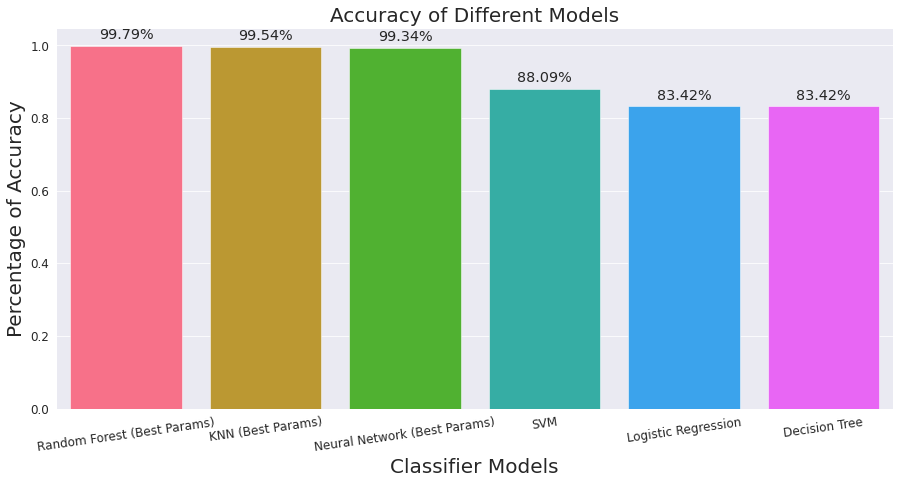

In [ ]:
plt.rcParams['figure.figsize']=15,7
sns.set_style('darkgrid')
ax = sns.barplot(x=df_score['Models'], y=df_score['Best Parameter'], palette = "husl", saturation =2.0)
plt.xlabel('Classifier Models', fontsize = 20 )
plt.ylabel('Percentage of Accuracy', fontsize = 20)
plt.title('Accuracy of Different Models', fontsize = 20)
plt.xticks(fontsize = 12, horizontalalignment = 'center', rotation = 8)
plt.yticks(fontsize = 12)
for i in ax.patches:
    width, height = i.get_width(), i.get_height()
    x, y = i.get_xy() 
    # ax.annotate(f'{round(height,2)}%', (x + width/2, y + height*1.02), ha='center', fontsize = 'x-large')
    ax.annotate(f'{round(height*100,2)}%', (x + width/2, y + height*1.02), ha='center', fontsize = 'x-large')
plt.show()